In [192]:
# Preparación del entorno (ejecutar en una terminal, no es necesario repetirla).
# python3.12 -m venv dlplnenv
# source dlplnenv/bin/activate
# python -m pip install --upgrade pip
# python -m pip install torch numpy pandas matplotlib jupyter
# No necesitamos scikit-learn para esta práctica.


# Guión de prácticas: Diseño de perceptrones multicapa en PyTorch

**Asignatura**: Deep Learning para procesamiento de Lenguaje Natural, 2026/2027

**Profesor**: Juan A. Botía (juanbot@um.es)

**Máster de Inteligencia Artificial**

**Facultad de Informática**

![](https://www.um.es/image/layout_set_logo?img_id=175281&t=1726728636242)

**Universidad de Murcia**

![](https://www.um.es/o/um-lr-principal-um-home-theme/images/logo-um.png)

# Contenidos
- [Introducción](#intro)
- [El dataset de partida](#dataset)
- [La capa básica de un MLP](#capabasicaaprendizaje)
- [De una capa a un MLP](#capamlp)
- [Un MLP configurable](#mlpconfigurable)
- [Funciones de activación en las capas ocultas](#activacion)
- [La salida expresa el significado de la tarea](#salida)
- [Decisiones de diseño a tomar](#disenio)
- [Bucle de entrenamiento del MLP](#bucle)
- [SGD versus Adam](#sgd)
- [Entrenar toda la red o solo una parte](#freeze)
- [Conclusiones](#conclusiones)
- [Ejercicios](#ejercicios)

<a class='anchor' id='intro'></a>
# Introducción

En la práctica anterior trabajamos con tensores: cómo crearlos, consultar su forma y operar con ellos. Ahora vamos a utilizar esos mismos tensores para construir redes neuronales. Usaremos [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/) como dataset ejemplo. Las medidas físicas de la población de pingüinos de la cohorte son fáciles de interpretar y permiten diseñar regresores y redes con varias salidas. No buscamos la arquitectura con mejores métricas ni resultados biológicos: buscamos entender formas de tensores, parámetros y flujo de información.

La pregunta central no será 

* ¿qué especie de pingüino predice la red?, sino 

* ¿qué estructura necesita una red para transformar una determinada entrada en una determinada salida?.

Un **perceptrón multicapa** (*Multi-Layer Perceptron*, MLP) transforma vectores mediante una sucesión de capas densas y funciones de activación. Diseñar un MLP requiere decidir qué representa cada componente de entrada, cuántas transformaciones queremos, qué dimensiones tienen las representaciones intermedias y qué significado damos a los valores de salida. Después elegimos una pérdida y un procedimiento de actualización que permitan aprender los parámetros.


## Objetivos

* Relacionar el número de variables con `in_features` y distinguirlo del tamaño del lote.
* Construir MLP con ninguna, una o varias capas ocultas; comparar anchura y profundidad.
* Entender `nn.Module`, `nn.Linear`, `nn.Sequential` y `forward()`.
* Variar las activaciones ocultas y las transformaciones a la salida.
* Elegir una pérdida compatible con la salida y el tensor objetivo.
* Separar arquitectura, objetivo de aprendizaje, optimizador y organización de los lotes.
* Observar una actualización con autograd y entrenar tanto un regresor como un autoencoder.

Nota sobre el dataset: El CSV está incrustado en una celda: los datos no requieren conexión. Las imágenes institucionales y enlaces sí requieren conexión.


In [193]:
import io
import base64
import zlib
import copy
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# CPU: suficiente para estas redes pequeñas y facilita comparar las ejecuciones.
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| Dispositivo:", device)


PyTorch: 2.2.2 | Dispositivo: cpu


<a class='anchor' id='dataset'></a>

# El dataset de partida

El dataset contiene 344 observaciones de pingüinos y medidas como longitud y profundidad del pico, longitud de la aleta y masa corporal, junto con especie, isla, sexo y año. 

La siguiente celda contiene una copia comprimida del CSV original de `palmerpenguins`. La compresión solo evita una celda con cientos de líneas: al descomprimir recuperamos el CSV y lo leemos con pandas. No se está entrenando un modelo ni codificando las variables en esta celda.

Fuente: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/), datos bajo **CC0**. Referencia: Horst, Hill y Gorman (2020), DOI: [10.5281/zenodo.3960218](https://doi.org/10.5281/zenodo.3960218). Datos recogidos por Kristen Gorman y Palmer Station LTER. 


In [194]:
# Datos incrustados; no necesita conexión a Internet.
PENGUINS_CSV_B64 = "eJyNW8mOJLkNvftbAgXty3FsA7755HujPZ3TU0D1gqo+eP7eEkkpQhKDSqBRQKFZLykujxTF/Pj5+P318XG8frx9/v7l+O/r29unt8f3r7/+/PTtG/765fETf/vj7fXnz8f79f9/fPnr07fPHx+fvh4fj/8dfz0+v//tty+Pt9fH8Z8f718f7x+P74fNL/rQ6SWWH/qw0avj2+e3x2GUiqy0P3R8cUU6HDYpdfzxEOSderFF9NDZH9b4jfS/fxv+3agQqq654mZ7WLcDtVXUqJdQ5FX5680B00uuB0xojmD8Ft1UbQIc0YXoRXSHxtake5G+PaczVWsDWrtqunuLgLoRoItTrHpCtnqlWCNKsk5XyFjPlkxx387ZxXbhMBp01hgcsi1AutoiHc5tpENVA/3iUe+dLjVKMPC2MeJMCeti7fon8SjiO81r/MMPV+y9ixEH5yx5k135JA77768fv/94kHNSdU4swI4/5CkcW+LWuJZwfQ1qiNSUb7O2CSeQg2gqtstcvpyiEEwGVWAdfqpQQ67qkeJOBQfZmuBHSRMvqFBEgZAI9yZGT5Nlwo0loDUfFgMyaqxu7PDP98fnb0SKQEsx3dIcycZu3SqbOZNdUTEiEmb1LWrRNTddnYwaathGzIubyO2fb1p+hsIFwvlrGBiF/CrYqWQZnN2jRf3GToFYvvKwePqiaa0wELElw1iG76f3UI7Svfu7RRPleLWUaNF2psK9WvQSsH8Glgk3jNdOX+MpYwaqzdnh8xPWCZYF6NPRlXj2UlDuP7vHfcyHyWuNOs8N+VS9fsOw3e/2rAt8JLUMzUjzEc3ph6OnNUN1i/pSQezl7LOo9bfKLqhQz2s5KPZUXsB0aCgN1GOyrKvGmhGwNkZJV2hAKKC8rKs6vW9HAl5QA5JUgIQyScRt2aehZg1N4WrZl2uwallfjZGgsVtykr6gQkTUsLMtxEF1nNn4DOmPqGJjhYIbsHk1I68xNgDbGqLVHapubFWiVnM2uPQaULpD614VDz30bMCFjroqTusLuoW2hDpj3shDrxsbJ6qRE3npQM1Bvg/ki+YeGTdjD6Y3mnusjh51iTvdCwcl4ukaeUZGx3oawJT6CXSs6rl1hDvLQKQEIo4nLGN6xFTd1QbddbvXZs88YZlMXX6tSiwzzbcvYJy1j+P9pFs82rH77dK97ljqd6rNb5Ko1zK401nkJ895s1d8i3wOccIyZJdszWG1203p6R2PvTTULDd0yXzW57scI1mg0tpKmduouNbyWnqM8jeVjzA73fn5QjFLUieBt0ieObqlTLtDxrk3mzVVLauNuqvR3VK6Vcj7jO6otmVz0dUKutqKGqjfvivShGp7f1rrCMvMSz9RXBWHNjovfF97Y6NK9MdL1zWL4XWObjwqSohwTaR+e2AyRrCFdEk+k0U9G7vTHcJLuOmk9oztgYBbC3O/HSgRVWPFL+mvRQugp6hSxChYNaH7PZRDm2RP+TqRQFbRYy/NGwtcVhuvkWQXXPNiGgcVfY2kb0YVIpJg3uFGGhfULFAc7jSdAfMuecBJR2RYTy7eYANzRWRDy4fDPFfqTGu5rJirJdazODeYvOYwH0zocs95caj0BjSPYb4Y8Jo7ZAjg6LS1SsGGBq628mqLjkNKsPhQ5Xlvpla1S6AYPl0GzX2LlalicOiZqkbF3uuNU83S2Ktn9L5exSyfkBdsi/2DgdzhvdmrUu/w7Fy/Z1m642J0O8f58VqVcAYa8d58i9rmpV7gul7pQ5O8J7te62ASrOFGarOgaySqW2v9LEn0lakr47j+8ukUC3aDivHbM1WyKnS00MLX2dZNhHVU5BboCjiuuPaP2LObeWqynL9NTv34IrDayZw9iWQnnE/3mbCTPGrbJHudTa9nSpf3gih9fuvz4tw7rVHqG4fpOV//9fj+68ePXmCgb7IwB9Q4Fr8OeUbhopuuzbax6vDXW8Qs6MDylTOAMObR0YrqQYG0QYUcrSMZo/3hnSQKSWJBtCgwzyEnYV99im8VxQbz4HpBjlXfOuTIhzeSEraGqy3gRmUchYi4qeI6PNw4QZtE4epqix5G0zBUwM3YG5vSeHovoXo02XOo6TSZPXyScVMTVXg9lLStJvOgRNzgmouD50Hvgmooxow+gpUDx1CMVZ9tYiFhLBTrGnN4K2jrFeLaJ8Ic7tM9zOfZMBfoKGyfiDGwbiJk0boYY/pJJTTZAWJXOpxDfS0EJFzA2uh5SfaaD4gYJE3TaVkaj++4poiW24qcDRFNZdG1RjYVBLjBkJnfLW+dqyK6QNAW52vAt0H0VkbUhAebJ7Rc7oZmhXFCuxwtNE4o0ZVlXIeD18aMXsB1FTXQwGCnbSRGKMLeSqhwWbIkajfagm2LCqXd8FGygUcWjxhf8yiEQ/UY3FHQ1cO9q14cIL68dCyLTsjAiW6eb/Asnjm2lZTwm0hwyAcWCV/vlDAXnrESbsCablDfeVq/xIKntqJGrohLeeaoA9nZQYPXDFGdoK1vqE+4gup51VXJDk7kszZA2znYE6qkqz0rWZp7MMYCrtGd24Qj5UNCXDnCWjnNUHl3Hostct3WY673CVaP9YHBbfSsF3pm8jfhDWPpce+O5s5+CSsZg0lPR8YUXkyyzzzpWty70dXDralGgt14LJJgIyXRXxAHAf0lxlfCJCdR/UTaJOzqtiHjTm1l0UQcXn0l2jV2u9YSPY/oJ7tqHChifQyiDYDoLBHdzrYe34QceixLHstnC2iKvtNIYtLXIIuTI65T/eW2F8+23eCwWsBVrTa4se4uqFQbEqFO190lamk7zZhSz8cJ7JINrmVYmr224Nb3IkrzNDINY4UaDahtihvb6taBeS9bFmm5applC5g2bwELOElTf3b3W8s2ntHosSB7DHDprpee8BhwrQnjjZdRwbXCX7I3D6OcJc0zhaLZuqFdN+tN2m7zQbcHAajnRrJDal7LWyvAkDc+EbUReRGvLi7LB8ut8yioXkZtVRd40bSVHcauqd34/QZT45SGOtt5pDSd356uzRtcmHs47A/8zrHt5qg2qK1ZNTjKmId/XB1H9soj1zLadlw7zz2Y2PKXGZhoBeoPNPaKVuYZaFdbJdtmbhuQQNrcxEHCODCQX0GcAUasYsQG8xviKLwucPMRiBdy/wS5uEYu5R4UpaN7NCiWmamLYAKgD77sTLL/+PP1+8ev988/27w0nC8WZn5XiIt4LYyZHqantcFFVPctgjrdHecYixoen57wAc/6aXVzwTbnK1gc5+Ystmkj6eVuzIiHvm/F7bvyx0ztCSfKxwxtB8ivg7s7A2bUO4rWducGeduV22DXUUFbMYlRNGBs+xDMbvrqmra6ocdlNdYx/SWubszGjdPxvRZmJ1tsr+CFF51i5UBNl69E7I6HLXrf45jH+4s4PbGYdSWQETZtioTfztipks4lMY2PV4KwxQ48cOucrPnCudg07b4zNunvbX7dZuYihFmDu3N4gtZHrfs9jK1h3Q+ExysR78W+jTVftRi6gZUUWEcar5sLsuobjevGPoOMFzOA1/MCERMfbRMfNpP8Blvjahb0jVpGpu0Y/J7P8G0LRjiiGgmXJ+ZJECMezrd5O4+5mOiADRGcie282LdHy19tvYjroDBr8uPXYDiL0J60VvMGHKOGaTvNEQudqIbCr6voc3NUwMZFUBLdHVAhn2YUD1PbxYiny1PpeHlmhPV1yXzqQHjz0V3bih2IpxdbimojqoHNLVBkrYm7IzpakHIYqvM+BqOKQwbRo9MZZNwJat/Tmy/ojPkifjkCslHJ2AaJ3XJ5zmDTF0+oGZL92CYxbbNmg42PkpgzW73xoQ8px4wUzCrSK4ybOz7WNS0jVdg6hy6CHlew5nvNjS+J+3bW9riCXg8Z5wUDpur61g6ZZ7IGqZJa5nEtjU9feuzQcoqRYyJ1klPW/B+O+hb9"
csv_text = zlib.decompress(base64.b64decode(PENGUINS_CSV_B64)).decode("utf-8")
penguins = pd.read_csv(io.StringIO(csv_text))
display(penguins.head())
print("Forma original:", penguins.shape)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Forma original: (344, 8)


## Detalles básicos sobre la organización del dataset de forma interna

Para predecir la masa corporal (BMG), usaremos inicialmente tres entradas: 

* longitud del pico, 

* profundidad del pico y 

* longitud de la aleta. 

La masa es la variable target y no puede introducirse también como entrada en este ejemplo: dar a la red la respuesta sería una fuga de información.

Una fila de la tabla que manejamos representa un pingüino y cada columna una variable. 

Si un lote tiene $B$ pingüinos y usamos $D=3$ variables, la forma del tensor que estaremos manejando es el de una matriz de dos dimensiones, con tamaños respectivos $(B,3)$. El tamaño del lote puede cambiar en diferentes partes del código; el número de variables debe coincidir con el diseño de la primera capa de la red neuronal que estemos manejando en cada momento.

Quitaremos las filas con valores ausentes en las cuatro medidas que necesitaremos. No es objetivo de esta clase imputar valores. Por eso, lo dejamos para la asignatura de Machine Learning. 

Separaremos entrenamiento y validación **antes** de calcular estadísticas de escalado. 

No utilizaremos un conjunto de prueba ni haremos selección de modelos: no es el objetivo de la práctica.


In [195]:
input_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
measurement_cols = input_cols + ["body_mass_g"]
df = penguins.dropna(subset=measurement_cols).reset_index(drop=True)

split_rng = np.random.default_rng(SEED)
indices = split_rng.permutation(len(df))
n_train = int(0.8 * len(df))
train_idx, val_idx = indices[:n_train], indices[n_train:]
df_train, df_val = df.iloc[train_idx], df.iloc[val_idx]
print("Filas completas:", len(df))
print("Entrenamiento:", len(df_train), "| Validación:", len(df_val))
display(df[measurement_cols].head())


Filas completas: 342
Entrenamiento: 273 | Validación: 69


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,36.7,19.3,193.0,3450.0
4,39.3,20.6,190.0,3650.0



La aleta se mide en cientos de milímetros, la masa en miles de gramos y el pico en decenas de milímetros. Esa diferencia de escalas afecta a las transformaciones y a los gradientes. Estandarizamos cada columna mediante $x'=(x-\mu)/\sigma$, usando exclusivamente estadísticas del entrenamiento.

También estandarizamos la masa. Así una salida negativa puede ser perfectamente válida: representa una masa por debajo de la media, no una masa física negativa. Para recuperar gramos usaremos $\hat y=\hat y'\sigma_y+\mu_y$.

`float32` es adecuado para pesos y entradas. Mantendremos el objetivo con forma **$(N,1)$**, no $(N,)$: esto evita un *broadcasting* accidental al calcular una pérdida entre predicción y objetivo.


In [196]:
def standardize_from_train(train_array, val_array):
    train_array = np.asarray(train_array, dtype=np.float32)
    val_array = np.asarray(val_array, dtype=np.float32)
    mean = train_array.mean(axis=0, keepdims=True)
    std = train_array.std(axis=0, keepdims=True)
    std = np.where(std > 0, std, 1.0)
    train_tensor = torch.tensor((train_array - mean) / std, dtype=torch.float32)
    val_tensor = torch.tensor((val_array - mean) / std, dtype=torch.float32)
    return train_tensor, val_tensor, mean, std

X_train, X_val, x_mean, x_std = standardize_from_train(
    df_train[input_cols].to_numpy(), df_val[input_cols].to_numpy())
y_train, y_val, y_mean, y_std = standardize_from_train(
    df_train[["body_mass_g"]].to_numpy(), df_val[["body_mass_g"]].to_numpy())

print("X:", X_train.shape, X_train.dtype)
print("y:", y_train.shape, y_train.dtype)
print("Primer pingüino estandarizado:", X_train[0])


X: torch.Size([273, 3]) torch.float32
y: torch.Size([273, 1]) torch.float32
Primer pingüino estandarizado: tensor([-0.9695,  0.0153, -0.7503])


<a class='anchor' id='capabasica'></a>

# La capa básica de un MLP

Una capa `nn.Linear(D,H)` transforma $D$ componentes de entrada en $H$ componentes de salida. Aunque se llama *Linear*, incluye un sesgo por defecto: es una transformación **afín**. Lo que quiere decir esto es que básicamente aplicamos una transformación lineal a los vectores de $D$, y les sumamos un vector de desplazamiento, el sesgo.

Para un lote $X\in\mathbb{R}^{B\times D}$, PyTorch almacena los pesos como $W\in\mathbb{R}^{H\times D}$ y calcula:

$$Z=XW^T+b,\qquad Z\in\mathbb{R}^{B\times H}.$$

El sesgo $b\in\mathbb{R}^{H}$ se añade a cada fila. La misma transformación se aplica a todos los pingüinos: **los parámetros no dependen del tamaño del lote**. Hay $D\cdot H+H$ parámetros si usamos sesgo. Los pesos empiezan con valores iniciales; aún no han aprendido nada de los pingüinos.


In [197]:
torch.manual_seed(SEED)
layer = nn.Linear(in_features=3, out_features=8)
batch = X_train[:5]
z = layer(batch)
manual_z = batch @ layer.weight.T + layer.bias
print("Entrada:", batch.shape)
print("Pesos:", layer.weight.shape, "| Sesgo:", layer.bias.shape)
print("Salida:", z.shape)
print("Parámetros:", sum(p.numel() for p in layer.parameters()))
print("Coincide con la operación matricial:", torch.allclose(z, manual_z))


Entrada: torch.Size([5, 3])
Pesos: torch.Size([8, 3]) | Sesgo: torch.Size([8])
Salida: torch.Size([5, 8])
Parámetros: 32
Coincide con la operación matricial: True


## Ejemplos de lotes de distinto tamaño y entradas incompatibles

Una capa `Linear(3,8)` admite lotes de 1, 5 o 20 filas, pero no puede procesar directamente vectores de cuatro componentes. Cambiar el lote no cambia la arquitectura; añadir una variable sí exige cambiar la primera capa. Capturamos el error siguiente deliberadamente para que el notebook continúe ejecutándose.


In [198]:
for B in [1, 5, 20]:
    print(f"Lote {B}:", tuple(layer(X_train[:B]).shape))

try:
    layer(torch.randn(5, 4))
except RuntimeError as error:
    print("Error esperado al usar 4 entradas en una capa diseñada para 3:")
    print(str(error).splitlines()[0])


Lote 1: (1, 8)
Lote 5: (5, 8)
Lote 20: (20, 8)
Error esperado al usar 4 entradas en una capa diseñada para 3:
mat1 and mat2 shapes cannot be multiplied (5x4 and 3x8)


<a class='anchor' id='capamlp'></a>
# Pasando de una capa a un MLP

Una **capa oculta** produce una representación intermedia que no es el objetivo de la tarea. Sus neuronas combinan las entradas; después una activación transforma los resultados. Las componentes ocultas no tienen por qué corresponder a «pico», «aleta» o cualquier medida física individual.

Diseñaremos una red $3\rightarrow8\rightarrow1$: tres variables de entrada, una capa oculta de ocho neuronas y una salida para la masa. Con activación $\phi$:

$$H=\phi(XW_1^T+b_1),\qquad \hat Y=HW_2^T+b_2.$$

`nn.Sequential` encadena módulos en orden. Cuando llamamos `model(X)`, PyTorch invoca el método `forward()` de la red. No debemos llamar a `forward()` directamente.

La última capa es lineal: permite predecir cualquier valor real en la escala estandarizada. Lección para llevar a casa: ¡¡Activación oculta y función de salida tienen papeles distintos!!.


In [199]:
torch.manual_seed(SEED)
simple_mlp = nn.Sequential(
    nn.Linear(3, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)
print(simple_mlp)
print("Salida para 5 pingüinos:", simple_mlp(X_train[:5]).shape)
print("Predicciones iniciales:\n", simple_mlp(X_train[:5]).detach())


Sequential(
  (0): Linear(in_features=3, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
Salida para 5 pingüinos: torch.Size([5, 1])
Predicciones iniciales:
 tensor([[0.1330],
        [0.1944],
        [0.2138],
        [0.1457],
        [0.0970]])


## Contar parámetros

Una red $3\rightarrow8\rightarrow1$ tiene $(3\cdot8+8)+(8\cdot1+1)=41$ parámetros. ReLU no añade pesos entrenables. Para dimensiones $d_0,\ldots,d_L$, el total de las capas densas con sesgo es:

$$P=\sum_{\ell=1}^{L}(d_{\ell-1}d_\ell+d_\ell).$$

El número de parámetros describe el tamaño de la red, pero **no garantiza** su calidad ni su capacidad práctica de generalizar.


In [200]:
def dense_parameter_count(dimensions):
    return sum(a * b + b for a, b in zip(dimensions[:-1], dimensions[1:]))

print("Cálculo teórico:", dense_parameter_count([3, 8, 1]))
print("Cálculo desde PyTorch:", sum(p.numel() for p in simple_mlp.parameters()))
display(pd.DataFrame([
    {"nombre": name, "forma": tuple(p.shape), "n_parámetros": p.numel()}
    for name, p in simple_mlp.named_parameters()
]))


Cálculo teórico: 41
Cálculo desde PyTorch: 41


,nombre,forma,n_parámetros
0,0.weight,"(8, 3)",24
1,0.bias,"(8,)",8
2,2.weight,"(1, 8)",8
3,2.bias,"(1,)",1


<a class='anchor' id='mlpconfigurable'></a>

# Un MLP configurable con `nn.Module`

`nn.Module` es la clase base de las redes en PyTorch. En `__init__()` registramos las capas y en `forward()` describimos el flujo. Registrarlas como atributos permite que PyTorch encuentre los parámetros y los gestione con `parameters()`, `state_dict()` o `to(device)`.

Cuando creemos el MLP, lo vamos a hacer de tal forma que podremos indicar:

* `input_dim`: número de componentes de entrada.
* `hidden_dims`: lista con la anchura de cada capa oculta. `[]` produce una única transformación afín, sin capas ocultas.
* `hidden_activation`: una activación común o una lista de activaciones, una por capa oculta.
* `output_dim`: número de salidas.
* `output_activation`: transformación final, independiente de las ocultas.

Crearemos una instancia distinta de activación en cada posición. `Identity` devuelve el tensor tal cual y nos permite representar una salida sin transformación adicional.


In [201]:
def make_activation(name):
    factories = {
        "identity": nn.Identity,
        "relu": nn.ReLU,
        "tanh": nn.Tanh,
        "sigmoid": nn.Sigmoid,
        "gelu": nn.GELU,
        "softplus": nn.Softplus,
        "softmax": lambda: nn.Softmax(dim=-1)
    }
    if name not in factories:
        raise ValueError(f"Activación desconocida: {name}")
    return factories[name]()

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim,
                 hidden_activation="relu", output_activation="identity"):
        super().__init__()
        hidden_dims = list(hidden_dims)
        if min([input_dim, output_dim] + hidden_dims) <= 0:
            raise ValueError("Las dimensiones deben ser positivas")
        names = ([hidden_activation] * len(hidden_dims)
                 if isinstance(hidden_activation, str)
                 else list(hidden_activation))
        if len(names) != len(hidden_dims):
            raise ValueError("Debe haber una activación por capa oculta")
        modules = []
        previous_dim = input_dim
        for width, activation_name in zip(hidden_dims, names):
            modules += [nn.Linear(previous_dim, width), make_activation(activation_name)]
            previous_dim = width
        self.features = nn.Sequential(*modules)
        self.head = nn.Linear(previous_dim, output_dim)
        self.output_activation = make_activation(output_activation)

    def forward(self, x):
        h = self.features(x)
        z = self.head(h)
        return self.output_activation(z)

    def representation(self, x):
        # Representación producida por el bloque de capas ocultas.
        return self.features(x)

configurable = MLP(3, [16, 8], 1, hidden_activation=["relu", "tanh"])
print(configurable)
print("Salida:", configurable(X_train[:5]).shape)
print("Representación final oculta:", configurable.representation(X_train[:5]).shape)


MLP(
  (features): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): Tanh()
  )
  (head): Linear(in_features=8, out_features=1, bias=True)
  (output_activation): Identity()
)
Salida: torch.Size([5, 1])
Representación final oculta: torch.Size([5, 8])


<a class='anchor' id='activacion'></a>

# Funciones de activación en las capas ocultas

Las activaciones introducen no linealidad. ReLU devuelve $\max(0,z)$; Tanh comprime a $(-1,1)$; Sigmoid a $(0,1)$; GELU es una transformación suave utilizada con frecuencia en arquitecturas modernas. Sus comportamientos y derivadas son distintos, y por eso pueden producir distintos flujos de gradiente.

* Sigmoid y Tanh pueden saturarse cuando la entrada tiene gran magnitud: sus derivadas se acercan a cero. 

* ReLU tiene derivada cero para entradas negativas y uno para positivas; en cero no es diferenciable y PyTorch utiliza una convención. 

Ninguna de estas funciones cambia por sí sola el número de neuronas.

Primero dibujamos valores y derivadas. La derivada se calcula con autograd sobre cada función, no a partir de una fórmula programada a mano. Cada gráfica es una herramienta para entender, no un criterio suficiente para elegir una activación.


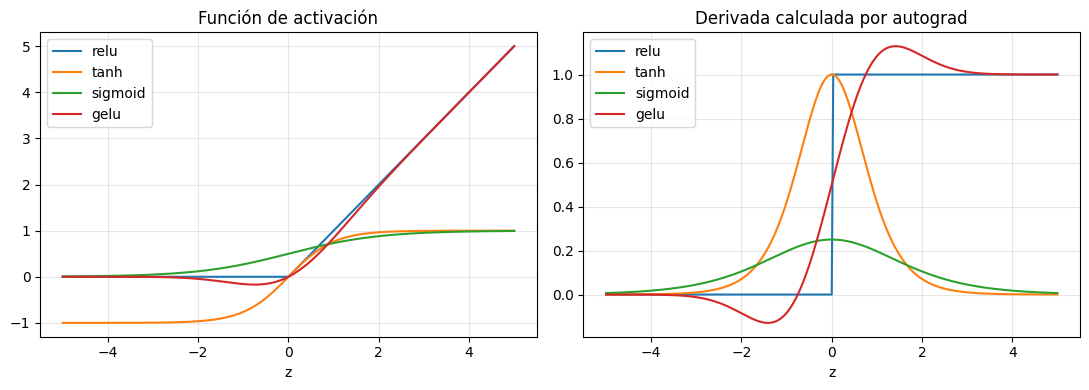

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in ["relu", "tanh", "sigmoid", "gelu"]:
    grid = torch.linspace(-5, 5, 301, requires_grad=True)
    values = make_activation(name)(grid)
    derivative, = torch.autograd.grad(values.sum(), grid)
    axes[0].plot(grid.detach().numpy(), values.detach().numpy(), label=name)
    axes[1].plot(grid.detach().numpy(), derivative.detach().numpy(), label=name)
axes[0].set_title("Función de activación")
axes[1].set_title("Derivada calculada por autograd")
for ax in axes:
    ax.set_xlabel("z")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


<a class='anchor' id='salida'></a>

# La salida expresa el significado de la tarea

La última capa indica cuántos valores producimos y a esos valores la transformación final decide qué dominio admiten. 

Conviene distinguir $z$, la salida de la última capa, de $g(z)$, la salida transformada. 

Los *logits* son puntuaciones reales previas a Sigmoid o Softmax, no probabilidades.

| Significado | Forma de salida | Transformación para interpretar | Pérdida habitual |
|---|---|---|---|
| Una magnitud real estandarizada | `(B,1)` | Identidad | `MSELoss` |
| Dos magnitudes reales | `(B,2)` | Identidad | `MSELoss` |
| Magnitud estrictamente positiva | `(B,1)` | `Softplus` | Una pérdida de regresión compatible con la escala |
| Un objetivo binario | `(B,1)` | Sigmoid | `BCEWithLogitsLoss` **sobre logits** |
| Tres clases excluyentes | `(B,3)` | Softmax sobre clases | `CrossEntropyLoss` **sobre logits** |
| Varias etiquetas no excluyentes | `(B,K)` | Sigmoid por componente | `BCEWithLogitsLoss` sobre logits |

Para una variable estandarizada, Sigmoid o Softplus pueden imponer un dominio incompatible. No usamos Softplus sobre la masa estandarizada porque puede ser negativa. Una salida de tres componentes no implica clasificación: también podría ser regresión de tres medidas.

**Importante**: `CrossEntropyLoss` y `BCEWithLogitsLoss` incorporan las transformaciones necesarias de forma numéricamente estable. No añadimos Softmax ni Sigmoid delante de ellas. `BCELoss` sí espera probabilidades; `NLLLoss` espera log-probabilidades. Estas últimas se incluyen como contraste conceptual, no se necesitan en la práctica.


In [203]:
demo_scores = torch.tensor([[-2.0, 0.0, 2.0], [1.0, 1.0, 1.0]])
display(pd.DataFrame({
    "logits": demo_scores.tolist(),
    "sigmoid independiente": torch.sigmoid(demo_scores).tolist(),
    "softmax excluyente": torch.softmax(demo_scores, dim=-1).tolist(),
    "suma de softmax": torch.softmax(demo_scores, dim=-1).sum(dim=-1).tolist()
}))
for name in ["identity", "sigmoid", "tanh", "softplus"]:
    values = make_activation(name)(torch.tensor([-3.0, 0.0, 3.0]))
    print(name, "->", values.tolist())


,logits,sigmoid independiente,softmax excluyente,suma de softmax
0,"[-2.0, 0.0, 2.0]","[0.11920291930437088, 0.5, 0.8807970285415649]","[0.01587624102830887, 0.11731042712926865, 0.8...",1.0
1,"[1.0, 1.0, 1.0]","[0.7310585975646973, 0.7310585975646973, 0.731...","[0.3333333432674408, 0.3333333432674408, 0.333...",1.0


identity -> [-3.0, 0.0, 3.0]
sigmoid -> [0.04742587357759476, 0.5, 0.9525741338729858]
tanh -> [-0.9950547814369202, 0.0, 0.9950547814369202]
softplus -> [0.04858734831213951, 0.6931471824645996, 3.0485873222351074]


<a class='anchor' id='disenio'></a>

# Decisiones de diseño a tomar

En este apartado vamos a ver cómo expandir lo que puede hacer una red. Vamos a pasar del paso **forward** en el que la red genera una salida a partir de una entrada mediante la secuencia de operaciones afines más activación dispuestas de forma secuencia, a estudiar ahora el **proceso de entrenamiento** de la red que consiste en ajustar esos pesos para reducir una pérdida, la función $L$. 

Conviene tener claro tres dimensiones diferentes que van a definir el *tipo de entrenamiento* particular que vamos a utilizar:

1. **Tipo de aprendizaje**: supervisado si tenemos un objetivo externo a usar como variable objetivo; auto-supervisado si lo construimos usando parte de los propios datos para reconstruir su forma original.
2. **Tamaño del lote de muestras usando en cada actualización de los pesos de la red**: por lote completo, usando mini-lotes o una muestra cada vez (versión estocástica).
3. **Regla de actualización**: SGD, Adam u otro optimizador. Todos funcionan aceptablemente en cualquier circunstancia, aunque `Adam` es un buen compromiso entre eficacia y eficiencia.

En cada actualización: 

* borramos gradientes anteriores, 

* calculamos predicción y pérdida, 

* obtenemos gradientes con `backward()` y 

* actualizamos con `step()`. 

PyTorch acumula gradientes por defecto, de ahí la necesidad de `zero_grad()` cuando no queremos acumulación.


In [204]:
torch.manual_seed(SEED)
#Definimos un MLP con 3 entradas, una capa oculta de 8 neuronas y 1 salida.
one_step_model = MLP(3, [8], 1)
#Definimos un optimizador SGD con tasa de aprendizaje 0.05 y una 
# función de pérdida MSE.
optimizer = torch.optim.SGD(one_step_model.parameters(), lr=0.05)
criterion = nn.MSELoss()
xb, yb = X_train[:16], y_train[:16]
weights_before = one_step_model.features[0].weight.detach().clone()

optimizer.zero_grad(set_to_none=True)
prediction = one_step_model(xb)
loss = criterion(prediction, yb)
loss.backward()
gradient = one_step_model.features[0].weight.grad
print("Pérdida antes de actualizar:", loss.item())
print("Forma del gradiente:", gradient.shape, "| Norma:", gradient.norm().item())
print("Backward aún no cambió los pesos:",
      torch.equal(weights_before, one_step_model.features[0].weight.detach()))
optimizer.step()
print("Norma del cambio tras step:",
      (one_step_model.features[0].weight.detach() - weights_before).norm().item())


Pérdida antes de actualizar: 0.9611184000968933
Forma del gradiente: torch.Size([8, 3]) | Norma: 0.3070078492164612
Backward aún no cambió los pesos: True
Norma del cambio tras step: 0.01535037998110056


<a class='anchor' id='bucle'></a>

# Bucle de entrenamiento del MLP

`TensorDataset` agrupa las entradas y objetivos correspondientes. `DataLoader` forma lotes y puede barajar las muestras. Una **época** recorre una vez los ejemplos de entrenamiento; una **actualización** corresponde a un `optimizer.step()`.

Usaremos una función que acepta una red, tensores, pérdida, optimizador y tamaño de lote. La pérdida que mostraremos al final de cada época se vuelve a calcular sobre todo el entrenamiento con los pesos de ese momento. Esto permite comparar sus valores con validación sin mezclar pérdidas obtenidas a lo largo de distintas actualizaciones.


In [205]:
# Esta función entrena el modelo recibido y registra la evolución
# de la pérdida en los conjuntos de entrenamiento y validación.
# Argumentos:
# model: red neuronal que queremos entrenar.
# Xtr: tensor con las entradas de entrenamiento.
# ytr: tensor con los valores objetivo de entrenamiento.
# Xva: tensor con las entradas de validación.
# yva: tensor con los valores objetivo de validación.
# epochs: número de recorridos completos por los datos de entrenamiento.
# batch_size: número de muestras utilizadas en cada actualización.
# optimizer_name: algoritmo de optimización, "sgd" o "adam".
# lr: tasa de aprendizaje; controla la magnitud de las actualizaciones.
# criterion: función de pérdida que compara predicciones y objetivos.
# seed: semilla que controla el orden aleatorio de los lotes.
#
# El asterisco (*) obliga a proporcionar los argumentos que le siguen
# mediante su nombre: por ejemplo, epochs=40.
#
# El modelo se modifica durante el entrenamiento. No se crea una copia.
# Se devuelve el historial de pérdidas y el número de actualizaciones.

def fit_model(model, Xtr, ytr, Xva, yva, *, epochs=80, batch_size=32,
              optimizer_name="adam", lr=0.01, criterion=None, seed=SEED):
    
    # Si no se proporciona una función de pérdida, usamos el error
    # cuadrático medio, habitual en problemas de regresión.
    # Con su configuración predeterminada, MSELoss devuelve la media
    # de los errores al cuadrado.
    if criterion is None:
        criterion = nn.MSELoss()

    # model.parameters() recorre los parámetros registrados en la red,
    # como los pesos y los sesgos de sus capas.
    #
    # requires_grad=True indica que autograd debe calcular gradientes
    # respecto a ese parámetro. Seleccionamos únicamente esos parámetros
    # para que el optimizador pueda actualizarlos.
    # Los parámetros congelados quedan fuera del optimizador.
    parameters = [p for p in model.parameters() if p.requires_grad]

    # Si todos los parámetros están congelados, o el modelo no contiene
    # parámetros, no hay nada que el optimizador pueda entrenar.
    if not parameters:
        raise ValueError("No hay parámetros entrenables")

    # Creamos un optimizador nuevo para esta llamada a fit_model.
    # El optimizador conserva referencias a los parámetros del modelo:
    # cuando ejecutemos optimizer.step(), modificará esos parámetros.
    if optimizer_name == "sgd":
        # SGD aplica aquí descenso de gradiente sin momentum.
        # Para cada parámetro θ, la actualización básica es:
        # θ ← θ - lr * gradiente_de_la_pérdida_respecto_a_θ
        optimizer = torch.optim.SGD(parameters, lr=lr)

    elif optimizer_name == "adam":
        # Adam mantiene medias móviles de los gradientes y de sus cuadrados.
        # Utiliza esa información para adaptar las actualizaciones
        # de cada parámetro durante el entrenamiento.
        optimizer = torch.optim.Adam(parameters, lr=lr)

    else:
        # Rechazamos cualquier nombre de optimizador no contemplado.
        raise ValueError("Usa sgd o adam")

    # Si batch_size=None, usamos todas las muestras en un único lote:
    # habrá una actualización por época (entrenamiento full batch).
    #
    # Si batch_size es menor que el número de muestras, trabajamos
    # con minibatches y hacemos varias actualizaciones por época.
    batch_size = len(Xtr) if batch_size is None else batch_size

    # Creamos un generador aleatorio específico para el DataLoader.
    # Su semilla permite reproducir la secuencia de órdenes de las muestras.
    #
    # Esto NO reinicializa los pesos del modelo ni controla por sí solo
    # todas las fuentes de aleatoriedad del entrenamiento.
    generator = torch.Generator().manual_seed(seed)

    # TensorDataset empareja cada entrada Xtr[i] con su objetivo ytr[i].
    #
    # DataLoader divide esas parejas en lotes de tamaño batch_size.
    # shuffle=True cambia aleatoriamente el orden en cada época,
    # manteniendo siempre cada entrada junto a su objetivo.
    #
    # Como no usamos drop_last=True, el último lote puede ser más pequeño.
    loader = DataLoader(
        TensorDataset(Xtr, ytr),
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    # Guardaremos una pérdida de entrenamiento y una de validación
    # al terminar cada época.
    history = {"train": [], "val": []}

    # Cuenta cuántas veces se han actualizado los parámetros.
    # Una actualización corresponde a un lote, no a una época.
    updates = 0

    def compute_loss(pred, target):
        # Función auxiliar que comprueba las dimensiones y calcula la pérdida.
        #
        # Para MSELoss y BCEWithLogitsLoss exigimos que predicciones
        # y objetivos tengan exactamente la misma forma.
        #
        # Por ejemplo, para una salida por muestra:
        # pred.shape   = (32, 1)
        # target.shape = (32, 1)
        #
        # En MSELoss, esta comprobación evita que el broadcasting
        # compare involuntariamente tensores de formas distintas,
        # como (32, 1) y (32,).
        if isinstance(criterion, (nn.MSELoss, nn.BCEWithLogitsLoss)):
            if pred.shape != target.shape:
                raise ValueError(
                    f"Formas incompatibles: {pred.shape} / {target.shape}"
                )

        # Aplicamos la función de pérdida seleccionada.
        # Este bucle espera una pérdida escalar, como la que producen
        # las pérdidas habituales con reduction="mean".
        return criterion(pred, target)

    # Cada época recorre una vez todos los lotes de entrenamiento.
    for epoch in range(epochs):

        # Activamos el modo entrenamiento.
        # Esto afecta a capas como Dropout y BatchNorm.
        # No calcula gradientes ni actualiza pesos por sí mismo.
        model.train()

        # xb contiene las entradas del lote actual.
        # yb contiene los objetivos correspondientes.
        for xb, yb in loader:

            # Eliminamos los gradientes del lote anterior, porque PyTorch
            # los acumula por defecto al llamar a backward().
            #
            # set_to_none=True deja los atributos .grad en None,
            # en lugar de rellenarlos con ceros.
            optimizer.zero_grad(set_to_none=True)

            # model(xb) realiza la propagación hacia delante:
            # transforma las entradas del lote en predicciones.
            #
            # compute_loss compara esas predicciones con yb.
            # Autograd registra las operaciones para poder calcular
            # después los gradientes.
            loss = compute_loss(model(xb), yb)

            # Comprobamos que la pérdida escalar no sea NaN ni infinita.
            # Si ocurre, detenemos el entrenamiento para revisar,
            # entre otras cosas, la escala de los datos y el learning rate.
            if not torch.isfinite(loss):
                raise RuntimeError(
                    "La pérdida no es finita; revisa escala y lr"
                )

            # Calculamos los gradientes de la pérdida mediante
            # retropropagación. Quedan almacenados en el atributo .grad
            # de los parámetros que han participado en el cálculo.
            #
            # backward() calcula gradientes; todavía no actualiza pesos.
            loss.backward()

            # El optimizador utiliza esos gradientes para actualizar
            # los parámetros entrenables del modelo.
            optimizer.step()

            # Registramos que se ha realizado una actualización.
            updates += 1

        # Tras entrenar con todos los lotes, activamos el modo evaluación.
        # Dropout deja de descartar activaciones y BatchNorm utiliza
        # sus estadísticas acumuladas, con su configuración habitual.
        #
        # eval() no desactiva el cálculo de gradientes: para eso usamos
        # el bloque torch.no_grad() que aparece a continuación.
        model.eval()

        with torch.no_grad():
            # Evaluamos el conjunto completo de entrenamiento con
            # los parámetros que tenemos al FINAL de esta época.
            #
            # No es la media de las pérdidas observadas durante los lotes:
            # es un nuevo cálculo con el modelo ya actualizado.
            #
            # item() convierte el tensor escalar en un número de Python.
            history["train"].append(
                compute_loss(model(Xtr), ytr).item()
            )

            # Evaluamos también el conjunto completo de validación.
            # Estos datos no se utilizan aquí para calcular gradientes
            # ni para actualizar los parámetros.
            history["val"].append(
                compute_loss(model(Xva), yva).item()
            )

    # El modelo recibido conserva los parámetros aprendidos y queda
    # en modo evaluación si se ha ejecutado al menos una época.
    #
    # history contiene las dos curvas de pérdida.
    # updates contiene el número total de pasos del optimizador.
    return history, updates


def plot_history(history, title):
    # Representa las pérdidas registradas por fit_model.
    # title es el texto que aparecerá como título de la gráfica.

    # Creamos una figura de 7 pulgadas de ancho y 3.5 de alto.
    plt.figure(figsize=(7, 3.5))

    # Dibujamos las pérdidas de entrenamiento.
    # Al no indicar valores para el eje X, Matplotlib usa 0, 1, 2, ...
    # Cada punto corresponde a la evaluación al final de una época:
    # el índice 0 representa el final de la primera época.
    plt.plot(history["train"], label="Entrenamiento")

    # Dibujamos las pérdidas de validación en los mismos ejes
    # para comparar su evolución con la del entrenamiento.
    plt.plot(history["val"], label="Validación")

    # Añadimos etiquetas a los ejes y el título.
    plt.xlabel("Época (índice desde 0)")
    plt.ylabel("Pérdida")
    plt.title(title)

    # Añadimos una cuadrícula tenue para facilitar la lectura.
    plt.grid(alpha=0.3)

    # Mostramos la leyenda con las etiquetas de las dos curvas.
    plt.legend()

    # Ajustamos los márgenes para evitar que los textos se recorten.
    plt.tight_layout()

    # Mostramos la gráfica.
    plt.show()

## Visualizando el entrenamiento al predecir el peso de los pingüinos

Entrenamos un MLP con estructura $$3\rightarrow16\rightarrow8\rightarrow1,$$ con ReLU, salida identidad y pérdida MSE. La variable target es una de las variables del dataset, por lo que es aprendizaje supervisado. 
Las curvas ayudan a comprobar que hay no hay sobreajuste (o overfitting), ni subajuste (o underfitting).


Actualizaciones: 900
MSE final de entrenamiento: 0.13031260669231415


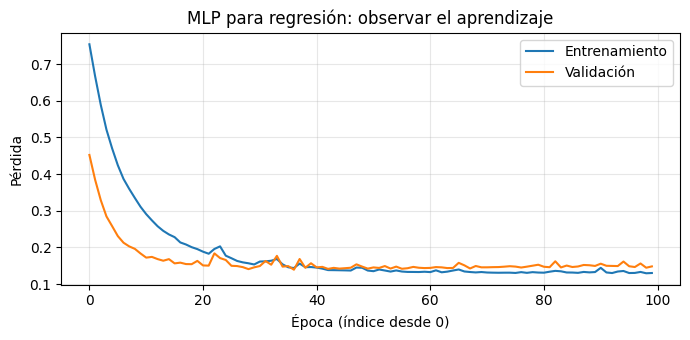

,masa observada (g),masa predicha (g)
0,3600.0,3455.800049
1,3650.0,3559.100098
2,3275.0,3527.399902
3,4100.0,4747.100098
4,5200.0,4986.600098


In [206]:
torch.manual_seed(SEED)
regressor = MLP(3, [16, 8], 1)
regression_history, regression_updates = fit_model(
    regressor, X_train, y_train, X_val, y_val,
    epochs=100, batch_size=32, optimizer_name="adam", lr=0.01)
print("Actualizaciones:", regression_updates)
print("MSE final de entrenamiento:", regression_history["train"][-1])
plot_history(regression_history, "MLP para regresión: observar el aprendizaje")
with torch.no_grad():
    mass_predictions = regressor(X_val[:5]).numpy() * y_std + y_mean
display(pd.DataFrame({
    "masa observada (g)": df_val["body_mass_g"].iloc[:5].to_numpy(),
    "masa predicha (g)": mass_predictions[:, 0].round(1)
}))


## Lote completo, mini-lotes y una muestra por actualización

Los tres esquemas pueden entrenar **la misma arquitectura** con el mismo objetivo:

* Lote completo: calcula una actualización por época usando todas las muestras.
* Mini-lotes: varias actualizaciones por época, tantas como $N/b$, siendo $N$ el tamaño total del dataset.
* Una muestra: una actualización por ejemplo; aquí seguimos recorriendo un dataset fijo, no un flujo continuo de datos nuevos.

Si hay $N$ ejemplos y tamaño de lote $B$, habrá $\lceil N/B\rceil$ actualizaciones por época. Más actualizaciones no equivalen **necesariamente** a mejor entrenamiento pero suelen dar mejor resultados aunque resulta más caro. Por otro lado, lotes de mayor tamaño requieren de una GPU con mauyor memoria pues el lote ha de albergarse en memoria en su totalidad.

Como se ve abajo, el MSE para una actualización-una muestra es mucho mejor aunque no hay que considerar únicamente ese factor para decidir qué esquema es el más conveniente.

In [207]:
torch.manual_seed(SEED)
batch_base = MLP(3, [8], 1)
batch_rows = []
for label, size in [("Completo", None), ("Mini-lote", 32), ("Una muestra", 1)]:
    candidate = copy.deepcopy(batch_base)
    history, updates = fit_model(candidate, X_train, y_train, X_val, y_val,
                                 epochs=12, batch_size=size,
                                 optimizer_name="sgd", lr=0.01)
    effective_size = len(X_train) if size is None else size
    batch_rows.append({
        "esquema": label, "tamaño lote": effective_size,
        "actualizaciones/época": math.ceil(len(X_train) / effective_size),
        "actualizaciones totales": updates,
        "MSE entrenamiento final": history["train"][-1]
    })
display(pd.DataFrame(batch_rows))


,esquema,tamaño lote,actualizaciones/época,actualizaciones totales,MSE entrenamiento final
0,Completo,273,1,12,0.925431
1,Mini-lote,32,9,108,0.313160
2,Una muestra,1,273,3276,0.177078


<a class='anchor' id='sgd'></a>

# SGD versus Adam

## SGD simple

Sea $\theta_{t-1}$ el vector de parámetros antes de la actualización $t$, $\eta$ el ratio de aprendizaje y $B_t$ el minibatch utilizado en el instante $t$. La pérdida del minibatch y su gradiente son:

$$
\mathcal{L}_{B_t}(\theta)
=
\frac{1}{|B_t|}
\sum_{i\in B_t}
\ell(f_\theta(x_i),y_i),
\qquad
g_t=\nabla_\theta\mathcal{L}_{B_t}(\theta_{t-1}).
$$

SGD actualiza los parámetros, como ya sabemos, mediante:

$$
\boxed{\theta_t=\theta_{t-1}-\eta g_t}.
$$

Y si lo particularizamos para cada parámetro $j$ tenemos:

$$
\theta_{t,j}=\theta_{t-1,j}-\eta g_{t,j}.
$$

La actualización utiliza directamente el gradiente del minibatch actual, con una tasa de aprendizaje común a todos los parámetros. Como $g_t()$ depende tanto de la función de pérdida como del modelo, se deja indicada.


## SGD con momentum

Sea $\theta_{t-1}$ el vector de parámetros antes de la actualización $t$, $\eta$ la tasa de aprendizaje y $g_t$ el gradiente de la pérdida sobre el minibatch $B_t$. Para $g_t$ conservamos la definición de arriba. Entonces, SGD con momentum mantiene un vector $v_t$ que acumula los gradientes actuales y anteriores. En el instante inicial, los inicializamos a cero, según $v_0=0$:

$$
v_t=\mu v_{t-1}+g_t,
$$

$$
\boxed{\theta_t=\theta_{t-1}-\eta v_t}
$$

El coeficiente $\mu\in[0,1)$ controla cuánto se conserva de los gradientes anteriores. Al desarrollar la recurrencia:

$$
v_t=\sum_{k=1}^{t}\mu^{t-k}g_k.
$$

Por tanto, la actualización utiliza una suma de gradientes cuyo peso disminuye exponencialmente con su antigüedad:

$$
\theta_t=\theta_{t-1}
-\eta\sum_{k=1}^{t}\mu^{t-k}g_k.
$$

Cuando los gradientes sucesivos en instantes sucesivos de tiempo $t_i, t_{i+1}, t_{i+2}, \ldots$ tienen direcciones similares, sus contribuciones se acumulan al coincidir en signo. Al acumularse refuerzan la dirección de desplazamiento marcada por el gradiente. Sin embargo, cuando cambian de signo, se compensan parcialmente, reduciendo las oscilaciones.

Si $\mu=0$, se recupera SGD sin momentum:

$$
\theta_t=\theta_{t-1}-\eta g_t.
$$

### Adam: estimación adaptativa de momentos

Adam utiliza el mismo gradiente $g_t$, pero mantiene dos medias móviles exponenciales, inicializadas con $m_0=v_0=0$:

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^{\odot 2}.
$$

$m_t$ estima el primer momento del gradiente y $v_t$ estima su segundo momento no centrado. $g_t^{\odot 2}$ representa el cuadrado elemento a elemento.

Para corregir el sesgo causado por la inicialización en cero:

$$
\widehat m_t=\frac{m_t}{1-\beta_1^t},
\qquad
\widehat v_t=\frac{v_t}{1-\beta_2^t}.
$$

La actualización de los parámetros es:

$$
\boxed{
\theta_t=\theta_{t-1}
-\eta\frac{\widehat m_t}{\sqrt{\widehat v_t}+\varepsilon}
}
$$

Todas las operaciones entre componentes se realizan elemento a elemento. Para cada parámetro $j$:

$$
\Delta\theta_{t,j}
=
-\frac{\eta}{\sqrt{\widehat v_{t,j}}+\varepsilon}
\widehat m_{t,j}.
$$

Adam utiliza una dirección basada en la media móvil de los gradientes y un factor de escala específico para cada parámetro. Los coeficientes $\beta_1,\beta_2\in[0,1)$ controlan la memoria de las medias móviles y $\varepsilon>0$ evita un denominador nulo.


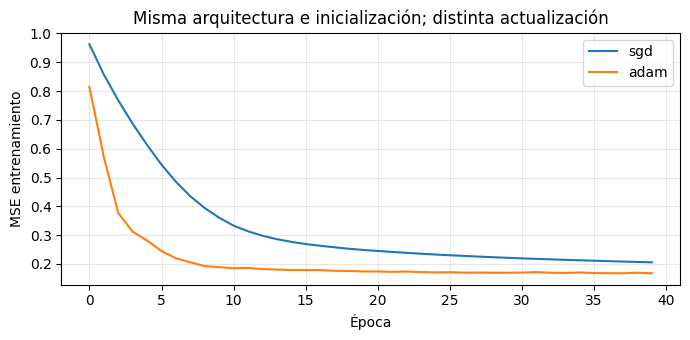

In [208]:
torch.manual_seed(SEED)
optimizer_base = MLP(3, [8], 1)
optimizer_histories = {}
for name in ["sgd", "adam"]:
    candidate = copy.deepcopy(optimizer_base)
    history, _ = fit_model(candidate, X_train, y_train, X_val, y_val,
                           epochs=40, batch_size=32, optimizer_name=name, lr=0.01)
    optimizer_histories[name] = history
plt.figure(figsize=(7, 3.5))
for name, history in optimizer_histories.items():
    plt.plot(history["train"], label=name)
plt.xlabel("Época")
plt.ylabel("MSE entrenamiento")
plt.title("Misma arquitectura e inicialización; distinta actualización")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


<a class='anchor' id='freeze'></a>

# Entrenar toda la red o solo una parte

También podemos decidir **qué parámetros** cambian. Congelar un bloque consiste en establecer `requires_grad=False` en sus parámetros. El único efecto que esto tiene es que para los parámetros correspondientes, sus gradientes no se calculan con lo que una llamada `step()` no tiene efecto en sus valores.

En el MLP ejemplo que estamos usando, 
```python
regressor = MLP(3, [16, 8], 1)
```

tenemos una estructura de nodos $$3\rightarrow 16\rightarrow 8\rightarrow 1$$. Si recordamos cómo hemos definido las variables `features` y `head`, veremos que la primera equivale a los parámetros de la parte de la red $$3\rightarrow 16\rightarrow 8,$$ y la segunda a la parte de la salida $$8\rightarrow 1.$$

En el código de abajo, copiamos el regresor ya entrenado y congelamos sus capas ocultas. Solo ajustamos `head`. Es una demostración mecánica sobre la misma tarea, no un experimento de transferencia a una población nueva. En transferencia real habría que justificar el modelo de origen y los datos de destino.

La función `fit_model` crea el optimizador solo con parámetros entrenables. `eval()` no congela pesos; `requires_grad=False` no sustituye a `eval()` para módulos con estado como BatchNorm.


In [209]:
head_only = copy.deepcopy(regressor)
for parameter in head_only.features.parameters():
    parameter.requires_grad_(False)
before_features = [p.detach().clone() for p in head_only.features.parameters()]
before_head = [p.detach().clone() for p in head_only.head.parameters()]
print("Parámetros totales:", sum(p.numel() for p in head_only.parameters()))
print("Parámetros entrenables:", sum(p.numel() for p in head_only.parameters()
                                      if p.requires_grad))
head_history, _ = fit_model(head_only, X_train, y_train, X_val, y_val,
                            epochs=10, batch_size=32, lr=0.005)
features_unchanged = all(torch.equal(old, new.detach())
                         for old, new in zip(before_features, head_only.features.parameters()))
head_changed = any(not torch.equal(old, new.detach())
                   for old, new in zip(before_head, head_only.head.parameters()))
print("Capas ocultas permanecen idénticas:", features_unchanged)
print("Algún parámetro de la cabeza cambió:", head_changed)
assert features_unchanged


Parámetros totales: 209
Parámetros entrenables: 9
Capas ocultas permanecen idénticas: True
Algún parámetro de la cabeza cambió: True


<a class='anchor' id='conclusiones'></a>

# Conclusiones

* La representación de los datos determina las dimensiones de entrada, no el número de ejemplos del lote.
* Una capa densa aprende una transformación afín; las activaciones ocultas introducen no linealidad.
* Una misma estructura puede participar en distintos objetivos; un mismo bucle puede entrenar redes diferentes.
* Supervisado/auto-supervisado, lote completo/mini-lotes y SGD/Adam responden a preguntas distintas.
* `backward()` calcula gradientes; `step()` actualiza los pesos. Modos de red y registro de gradientes tampoco son lo mismo.


<a class='anchor' id='ejercicios'></a>
# Ejercicios sobre perceptrones multicapa

Realiza los ejercicios en las celdas siguientes. Antes de ejecutar, escribe las formas esperadas y justifica tus decisiones. No se pide maximizar exactitud de clasificación. Mantén la separación entrenamiento/validación y calcula los escalados con entrenamiento.


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Ejercicio 1: Entradas y tamaño del lote</strong></div>

* Diseña un MLP con dos entradas (longitud del pico y aleta), una capa oculta de 6 neuronas y una salida para masa.
* Ejecuta lotes de 1, 7 y 20 pingüinos usando `X2_train` y escribe la forma en cada paso.
* Calcula los parámetros a mano y comprueba el resultado con PyTorch.
* Explica por qué cambiar el lote no exige rediseñar la red, pero añadir una variable sí.


In [210]:
# Ejercicio 1: desarrolla aquí tu propuesta.
# Escribe primero las dimensiones y la justificación.


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Ejercicio 2: Anchura y profundidad</strong></div>

* Construye las estructuras `3 -> 12 -> 1` y `3 -> 6 -> 6 -> 1`.
* Cuenta capas ocultas y parámetros de cada red antes de ejecutar.
* Comprueba las formas usando cinco filas de `X_train`.
* Explica por qué más profundidad no implica necesariamente más parámetros ni una red mejor.


In [211]:
# Ejercicio 2: desarrolla aquí tu propuesta.
# Escribe primero las dimensiones y la justificación.


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Ejercicio 3: Activaciones por capa</strong></div>

* Construye `3 -> 10 -> 5 -> 1` con Tanh en la primera capa oculta y ReLU en la segunda.
* Muestra las formas de cada transformación y la representación final oculta.
* Sustituye las activaciones por identidad y comprueba que la salida sigue teniendo la misma forma.
* Explica qué cambia en la familia de funciones que la red puede representar.
* Opcional: calcula los pesos y sesgo de una única capa afín equivalente a la red sin activaciones.


In [212]:
# Ejercicio 3: desarrolla aquí tu propuesta.
# Escribe primero las dimensiones y la justificación.


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Ejercicio 4: Salida, objetivo y pérdida</strong></div>

* Diseña una red para predecir aleta y masa desde las dos medidas del pico: reutiliza `Xm_train` y `ym_train`.
* Justifica dimensión de salida, activación final y pérdida, y calcula una pérdida inicial.
* Explica por qué Sigmoid no es una buena salida para objetivos estandarizados que pueden ser negativos.
* Diseña, sin entrenar, una cabeza de tres clases excluyentes: indica formas y tipos de logits y objetivos.
* Explica por qué no debes colocar Softmax antes de `CrossEntropyLoss`.


In [213]:
# Ejercicio 4: desarrolla aquí tu propuesta.
# Escribe primero las dimensiones y la justificación.


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Ejercicio 5: Una actualización observable</strong></div>

* Crea un MLP `3 -> 8 -> 1` y guarda una copia de sus pesos iniciales.
* Realiza `zero_grad`, `forward`, MSE y `backward` con un lote de 8 muestras.
* Imprime formas y normas de gradientes y comprueba que aún no cambiaron los pesos.
* Ejecuta `step` con SGD y comprueba el cambio de parámetros.
* Explica qué ocurriría si repitieras `backward` de un nuevo forward sin borrar los gradientes.


In [214]:
# Ejercicio 5: desarrolla aquí tu propuesta.
# Escribe primero las dimensiones y la justificación.


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Ejercicio 6: Presupuesto de entrenamiento</strong></div>

* Desde una misma inicialización, entrena con lote completo y con mini-lotes de 16.
* Mantén 10 épocas y registra cuántas actualizaciones realiza cada método.
* Explica por qué esa comparación no mantiene fijo el número de actualizaciones.
* Propón un diseño que mantenga un presupuesto fijo de actualizaciones; no hace falta programarlo.
* Identifica qué cambias si sustituyes SGD por Adam y qué permanece igual.


In [215]:
# Ejercicio 6: desarrolla aquí tu propuesta.
# Escribe primero las dimensiones y la justificación.


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Ejercicio 7: Un autoencoder con otro cuello de botella</strong></div>

* Modifica `PenguinAutoencoder` para usar una componente latente.
* Escribe las dimensiones completas de encoder y decoder y cuenta sus parámetros.
* Entrena con `Xa_train` como entrada y objetivo; usa validación de reconstrucción.
* Compara estructuralmente el cuello de botella de 1 con el de 2 componentes.
* Justifica por qué la salida tiene 4 componentes y no el número de especies.


In [216]:
# Ejercicio 7: desarrolla aquí tu propuesta.
# Escribe primero las dimensiones y la justificación.


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Ejercicio 8: Congelar y descongelar</strong></div>

* Copia el regresor y congela únicamente la primera capa densa de `features`.
* Imprime qué parámetros son entrenables y cuántos elementos suman.
* Entrena unas pocas épocas y verifica que la capa congelada no cambió.
* Descongélala y crea un nuevo optimizador o llama de nuevo a `fit_model`.
* Explica por qué `eval()` por sí solo no congela parámetros.


In [217]:
# Ejercicio 8: desarrolla aquí tu propuesta.
# Escribe primero las dimensiones y la justificación.


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Ejercicio 9: Diseño razonado de una red nueva</strong></div>

* Elige dos variables numéricas como entrada y una medida distinta como objetivo, sin incluir la respuesta en las entradas.
* Define escalado, lista de capas ocultas, activaciones y transformación de salida.
* Justifica formas, parámetros, pérdida, esquema de lotes y optimizador.
* Ejecuta un forward y un entrenamiento breve, verificando compatibilidad de formas.
* Describe qué decisiones afectan a la arquitectura y cuáles al aprendizaje. No se pide comparar clasificación.


In [218]:
# Ejercicio 9: desarrolla aquí tu propuesta.
# Escribe primero las dimensiones y la justificación.


## Documentación y referencias

* [PyTorch: `nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html).
* [PyTorch: `nn.Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html) y [`nn.Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html).
* [Funciones de activación](https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity).
* [MSELoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html), [BCEWithLogitsLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) y [CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).
* [Autograd](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html) y [bucle de optimización](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).
* [Datos y atribución de Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/). [CSV original](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv).

Las comparaciones son demostraciones didácticas con una partición y una semilla; no prueban que una arquitectura, activación u optimizador sea superior. La reproducibilidad exacta puede variar entre versiones y plataformas.
